## Dataset loading

In [9]:
!pip install opencv-python scikit-image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import skimage



In [10]:
import os
print(os.getcwd())
print(os.listdir())

/Users/grantcaile/Projects/cs135-26s-assignments/cs135-ProjectB/cs135-ProjectB
['Problem1.ipynb', 'yproba1_test.txt', 'README.md', 'x_train.csv', 'x_test_img.npz', 'starter_notebook.ipynb', '.git', 'y_train.csv', 'x_test_engineered_features.csv', 'Engineered_Features.ipynb', 'x_train_img.npz', 'x_test.csv', 'x_train_engineered_features.csv']


In [11]:
img_file = "x_test_img.npz"
metadata_file = "x_test.csv"
X_dev = pd.read_csv(metadata_file)

In [12]:
# Function and code to load images
def load_img_data(file_path):
    with np.load(file_path) as data:
        img = data['images']
        ids = data['image_ids']
    print(f"Successfully loaded {img.shape[0]} images.")
    return img, ids

imgs, img_ids = load_img_data(img_file)
print(img_ids.shape, imgs.shape)

# Make sure the IDs match and are in the same order
assert np.all(img_ids == X_dev['img_id']), "Image IDs in metadata and image data do not match"

Successfully loaded 296 images.
(296,) (296, 256, 256, 3)


## Feature Creation

In [13]:
# Setup
features = pd.DataFrame()
cv_imgs = [cv2.cvtColor(x, cv2.COLOR_RGB2BGR) for x in imgs]
np.asarray(cv_imgs).shape

(296, 256, 256, 3)

### Color variation

In [14]:
means = []
stds = []
for image in cv_imgs:
    mean, std = cv2.meanStdDev(image)
    means.append(mean.flatten())
    stds.append(std.flatten())

means = np.array(means)
stds = np.array(stds)

print(means.shape, stds.shape)

(296, 3) (296, 3)


In [15]:
features['B_mean'] = means[:, 0]
features['G_mean'] = means[:, 1]
features['R_mean'] = means[:, 2]

features['B_std'] = stds[:, 0]
features['G_std'] = stds[:, 1]
features['R_std'] = stds[:, 2]

### Mean intensity

In [16]:
# Make grayscale
gcv_imgs = [cv2.cvtColor(x, cv2.COLOR_BGR2GRAY) for x in cv_imgs]

intensities = []
for image in gcv_imgs:
    mean = cv2.mean(image)
    intensities.append(mean[0])

np.asarray(intensities).shape

(296,)

In [17]:
features['intensity'] = intensities

### Level of symmetry

In [18]:
symmetries = []
for image in gcv_imgs:
    flipped = cv2.flip(image, 1)
    ssim = skimage.metrics.structural_similarity(image, flipped)
    symmetries.append(ssim)

np.asarray(symmetries).shape

(296,)

In [19]:
features['symmetry'] = symmetries

### Inner - outer region difference

In [20]:
# Create masks for separating the inner and outer regions
inner_mask = np.zeros(imgs[0].shape[0:2])
cv2.circle(inner_mask, (128, 128), 60, 1, -1)
outer_mask = np.ones(imgs[0].shape[0:2]) - inner_mask

inner_mask = np.stack([inner_mask]*3, axis=2)
outer_mask = np.stack([outer_mask]*3, axis=2)

inner_area = np.sum(inner_mask)
outer_area = np.sum(outer_mask)

print(inner_area, outer_area)
print(inner_mask.shape, outer_mask.shape)

33867.0 162741.0
(256, 256, 3) (256, 256, 3)


In [21]:
# BGR mean difference
io_mean_diffs = []
for image in cv_imgs:
    inner_sums = cv2.sumElems(image * inner_mask)
    inner_means = inner_sums[0:3] / np.array([inner_area]*3)

    outer_sums = cv2.sumElems(image * outer_mask)
    outer_means = outer_sums[0:3] / np.array([outer_area]*3)

    mean_diff = np.abs(inner_means - outer_means)
    io_mean_diffs.append(mean_diff)

io_mean_diffs = np.array(io_mean_diffs)
io_mean_diffs.shape

(296, 3)

In [22]:
features['B_io_mean_diff'] = io_mean_diffs[:,0]
features['G_io_mean_diff'] = io_mean_diffs[:,1]
features['R_io_mean_diff'] = io_mean_diffs[:,2]

In [23]:
# Grayscale intensity mean difference
io_intensity_diffs = []
for image in gcv_imgs:
    inner_sum = np.sum(image * inner_mask[:,:,0])
    inner_mean = inner_sum / (inner_area / 3)

    outer_sum = np.sum(image * outer_mask[:,:,0])
    outer_mean = outer_sum / (outer_area / 3)

    mean_diff = np.abs(inner_mean - outer_mean)
    io_intensity_diffs.append(mean_diff)

io_intensity_diffs = np.array(io_intensity_diffs)
io_intensity_diffs.shape

(296,)

In [24]:
features['intensity_io_diff'] = io_intensity_diffs

### Area

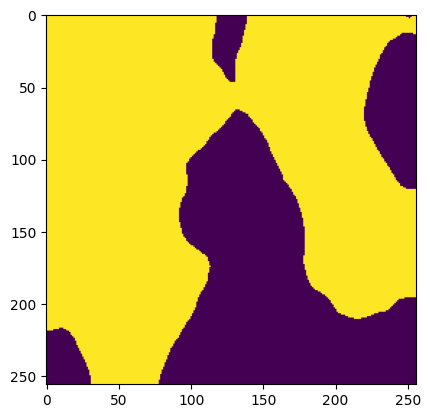

In [25]:
areas = []
for image in gcv_imgs:
    # Apply Gaussian blur to reduce noise while preserving edges.
    blurred = cv2.GaussianBlur(image, (31,31), sigmaX=30, sigmaY=None)

    # Otsu thresholding
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    plt.imshow(thresh)
    plt.show()
    break

### Histogram

In [26]:
n_bins=8
hist_features = []
for img in cv_imgs:
    h_features = []
    for channel in range(3): 
        hist, garbage = np.histogram(img[:, :, channel], bins=n_bins, range=(0, 255))
        hist = hist / hist.sum() 
        h_features.extend(hist)
    hist_features.append(h_features)
hist_features = np.array(hist_features) 

for i, name in enumerate(['B_bin1','B_bin2','B_bin3','B_bin4','B_bin5','B_bin6','B_bin7','B_bin8',
                           'G_bin1','G_bin2','G_bin3','G_bin4','G_bin5','G_bin6','G_bin7','G_bin8',
                           'R_bin1','R_bin2','R_bin3','R_bin4','R_bin5','R_bin6','R_bin7','R_bin8']):
    features[name] = hist_features[:, i]




### Edge Features


In [27]:
all_edge_density = []
all_edge_std = []

for img in gcv_imgs:
    edges = cv2.Canny(img, threshold1=50, threshold2=150)
    
    edge_density = edges.mean()         
    edge_std = edges.std()               
    
    all_edge_density.append(edge_density)
    all_edge_std.append(edge_std)

features['edge_density'] = np.array(all_edge_density)
features['edge_std'] = np.array(all_edge_std)

## Saving the new features

In [ ]:
features.to_csv('x_test_engineered_features.csv', index = False)